# CMI - DetectBehavior with Sensor Data Japanese Tutorial
このノートブックの概要と目的、abstract的な内容

## やることリスト(自分用)

- ~~完成ロードマップの作成~~
- ~~データセットの把握と前処理~~
- EDA
- 特徴量エンジニアリング(ガウスフィルターとかもやりたい)
- モデリング
- 解説の記述
- 見直し
- 参考にしたノートブックの記述
- メッセージの記述

**<アイデア>**    
- バイアスチェック

### コンペの概要

コンペの概要を書く

### データセットの把握と前処理
データセットを加工してEDAや学習、予測で扱いやすく加工する
- データセットの形状の整形
- 重複値の除去
- 欠損値の除去

In [23]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple
import plotly.graph_objects as go
import ast # 文字列をPythonオブジェクトとして安全に評価するために使用

pd.set_option('display.max_rows', None)

# Set professional plotting style
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'Arial'
custom_palette = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]
sns.set_palette(custom_palette)

In [2]:
# データセットのロード
BASE_DIR = "./data"
train_df = pd.read_csv(BASE_DIR + "/train.csv")
train_dem_df = pd.read_csv(BASE_DIR +"/train_demographics.csv")
test_df = pd.read_csv(BASE_DIR + "/test.csv")
test_dem_df = pd.read_csv(BASE_DIR + "/test_demographics.csv")

# データセット名と対応するdfの辞書を作成
datasets = {
    "Train Data": train_df,
    "Train Demographics": train_dem_df,
    "Test Data": test_df,
    "Test Demographics": test_dem_df,
}

In [3]:
# train dataを見てみる
display(train_df.head(2))
display(train_dem_df.head(2))

,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


,subject,adult_child,age,sex,handedness,height_cm,shoulder_to_wrist_cm,elbow_to_wrist_cm
0,SUBJ_000206,1,41,1,1,172.0,50,25.0
1,SUBJ_001430,0,11,0,1,167.0,51,27.0


In [4]:
# test dataを見てみる
display(test_df.head(2))
display(test_dem_df.head(2))

,row_id,sequence_id,sequence_counter,subject,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000001_000000,SEQ_000001,0,SUBJ_055840,9.039062,5.261719,0.800781,0.367188,-0.397400,-0.629028,...,97.0,87.0,206.0,-1.0,195.0,-1.0,-1.0,-1.0,111.0,-1.0
1,SEQ_000001_000001,SEQ_000001,1,SUBJ_055840,9.421875,3.460938,-1.113281,0.353882,-0.507141,-0.652710,...,175.0,158.0,-1.0,-1.0,-1.0,-1.0,-1.0,211.0,187.0,178.0


,subject,adult_child,age,sex,handedness,height_cm,shoulder_to_wrist_cm,elbow_to_wrist_cm
0,SUBJ_016452,1,25,1,1,165.0,52,23.0
1,SUBJ_055840,0,13,0,1,177.0,52,27.0


In [5]:
# 各データセットの形状の確認
print("<Check Shape>")
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

<Check Shape>
Train Data: (574945, 341)
Train Demographics: (81, 8)
Test Data: (107, 336)
Test Demographics: (2, 8)


データセットの形状は学習時や予測時のモデルの入力する部分で重要になってきます。...

In [6]:
# 各データセットに欠損値がないかを調べる
# 出力結果は折りたたまれるため、テキストエディタの機能で展開して確認してください。
# df.info()でもいい
print("<Check Null Values>")
for name, df in datasets.items():
    null_num = df.isnull().sum()
    print("---"*20 + f"\n{name}")
    display(null_num)

<Check Null Values>
------------------------------------------------------------
Train Data


row_id                  0
sequence_type           0
sequence_id             0
sequence_counter        0
subject                 0
orientation             0
behavior                0
phase                   0
gesture                 0
acc_x                   0
acc_y                   0
acc_z                   0
rot_w                3692
rot_x                3692
rot_y                3692
rot_z                3692
thm_1                6987
thm_2                7638
thm_3                6472
thm_4                6224
thm_5               33286
tof_1_v0             6224
tof_1_v1             6224
tof_1_v2             6224
tof_1_v3             6224
tof_1_v4             6224
tof_1_v5             6224
tof_1_v6             6224
tof_1_v7             6224
tof_1_v8             6224
tof_1_v9             6224
tof_1_v10            6224
tof_1_v11            6224
tof_1_v12            6224
tof_1_v13            6224
tof_1_v14            6224
tof_1_v15            6224
tof_1_v16            6224
tof_1_v17   

------------------------------------------------------------
Train Demographics


subject                 0
adult_child             0
age                     0
sex                     0
handedness              0
height_cm               0
shoulder_to_wrist_cm    0
elbow_to_wrist_cm       0
dtype: int64

------------------------------------------------------------
Test Data


row_id              0
sequence_id         0
sequence_counter    0
subject             0
acc_x               0
acc_y               0
acc_z               0
rot_w               0
rot_x               0
rot_y               0
rot_z               0
thm_1               0
thm_2               0
thm_3               0
thm_4               0
thm_5               0
tof_1_v0            0
tof_1_v1            0
tof_1_v2            0
tof_1_v3            0
tof_1_v4            0
tof_1_v5            0
tof_1_v6            0
tof_1_v7            0
tof_1_v8            0
tof_1_v9            0
tof_1_v10           0
tof_1_v11           0
tof_1_v12           0
tof_1_v13           0
tof_1_v14           0
tof_1_v15           0
tof_1_v16           0
tof_1_v17           0
tof_1_v18           0
tof_1_v19           0
tof_1_v20           0
tof_1_v21           0
tof_1_v22           0
tof_1_v23           0
tof_1_v24           0
tof_1_v25           0
tof_1_v26           0
tof_1_v27           0
tof_1_v28           0
tof_1_v29 

------------------------------------------------------------
Test Demographics


subject                 0
adult_child             0
age                     0
sex                     0
handedness              0
height_cm               0
shoulder_to_wrist_cm    0
elbow_to_wrist_cm       0
dtype: int64

トレーニングデータには多数の欠損値が存在するため補完する必要がある"<br>
欠損値を保管する処理を行う

In [7]:
# 欠損値を線形補間する処理を行う
null_columns = [col for col in train_df.columns if col.startswith(('rot_', 'thm_', 'tof_'))]          # ToFセンサーの列名リストを作成
train_df[null_columns] = train_df[null_columns].interpolate(method='linear', limit_direction='both')  # ToFセンサーの列に対してのみ線形補間を適用
print(train_df[null_columns].isnull().sum().sum())                                                    # 補間後に残っているNaNがないか確認

0


よって欠損値は補完された

In [8]:
# 各データセットに重複値がないかを調べる
print("<Check Duplicated rows num>")
for name, df in datasets.items():
    duplicate_num = df.duplicated().sum()
    print(f"{name}: {duplicate_num}")

<Check Duplicated rows num>
Train Data: 0
Train Demographics: 0
Test Data: 0
Test Demographics: 0


重複はないため...と言える

In [9]:
# 最後にinfo()でデータを最終チェックする
print("<Check infomation>")
for name, df in datasets.items():
    print("---"*20 + f"\n{name}")
    display(df.info())

<Check infomation>
------------------------------------------------------------
Train Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574945 entries, 0 to 574944
Columns: 341 entries, row_id to tof_5_v63
dtypes: float64(332), int64(1), object(8)
memory usage: 1.5+ GB


None

------------------------------------------------------------
Train Demographics
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject               81 non-null     object 
 1   adult_child           81 non-null     int64  
 2   age                   81 non-null     int64  
 3   sex                   81 non-null     int64  
 4   handedness            81 non-null     int64  
 5   height_cm             81 non-null     float64
 6   shoulder_to_wrist_cm  81 non-null     int64  
 7   elbow_to_wrist_cm     81 non-null     float64
dtypes: float64(2), int64(5), object(1)
memory usage: 5.2+ KB


None

------------------------------------------------------------
Test Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Columns: 336 entries, row_id to tof_5_v63
dtypes: float64(332), int64(1), object(3)
memory usage: 281.0+ KB


None

------------------------------------------------------------
Test Demographics
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject               2 non-null      object 
 1   adult_child           2 non-null      int64  
 2   age                   2 non-null      int64  
 3   sex                   2 non-null      int64  
 4   handedness            2 non-null      int64  
 5   height_cm             2 non-null      float64
 6   shoulder_to_wrist_cm  2 non-null      int64  
 7   elbow_to_wrist_cm     2 non-null      float64
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


None

In [10]:
# 統計量を調べる
print("<Check describe>")
print("---"*20 + f"\ntrain")
display(train_df.describe())
print("-"*20 + f"\ntrain demographics")
display(train_dem_df.describe())

<Check describe>
------------------------------------------------------------
train


,sequence_counter,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z,thm_1,thm_2,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
count,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,...,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000,574945.000000
mean,43.645234,1.639980,1.790704,-0.459811,0.360271,-0.119899,-0.060106,-0.188147,27.077655,27.130502,...,29.632411,26.042100,45.494813,43.351055,40.216210,37.798595,34.944456,31.936506,29.155075,27.400090
std,45.717673,5.781259,5.003945,6.096490,0.225486,0.465005,0.542345,0.503484,3.220003,2.931869,...,57.786338,53.771757,67.884665,67.463481,66.411717,64.763328,62.575082,59.898065,56.773746,55.016799
min,0.000000,-34.585938,-24.402344,-42.855469,0.000000,-0.999146,-0.999695,-0.998169,-0.370413,21.958820,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,17.000000,-2.964844,-2.121094,-5.417969,0.180420,-0.455994,-0.510986,-0.626465,24.764587,24.551666,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,35.000000,2.972656,0.695312,-1.562500,0.340210,-0.186523,-0.112854,-0.263611,26.981247,26.362631,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
75%,54.000000,6.343750,6.816406,5.164062,0.503052,0.203979,0.438416,0.249756,29.417263,29.598019,...,36.000000,26.000000,81.000000,77.000000,67.000000,60.000000,52.000000,43.000000,36.352113,32.000000
max,699.000000,46.328125,27.183594,30.078125,0.999390,0.999817,0.999451,0.999878,38.457664,37.578339,...,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000


--------------------
train demographics


,adult_child,age,sex,handedness,height_cm,shoulder_to_wrist_cm,elbow_to_wrist_cm
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,0.518519,21.814815,0.617284,0.876543,167.993827,51.580247,25.469136
std,0.502770,10.289693,0.489078,0.331010,10.605863,4.888415,3.025254
min,0.000000,10.000000,0.000000,0.000000,135.000000,41.000000,18.000000
25%,0.000000,13.000000,0.000000,1.000000,163.000000,49.000000,24.000000
50%,1.000000,22.000000,1.000000,1.000000,170.000000,52.000000,25.000000
75%,1.000000,27.000000,1.000000,1.000000,174.000000,55.000000,27.000000
max,1.000000,53.000000,1.000000,1.000000,190.500000,71.000000,44.000000


### EDA 1 (マクロ分析)
センサーデータ以外のデータの特性を調べる


--- train: カテゴリカル変数の分布 ---


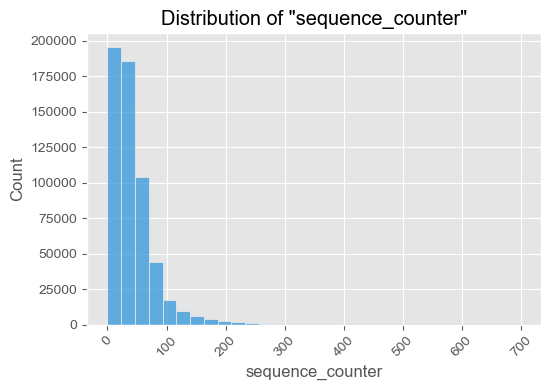


--- train demographics: 数値変数の分布 ---


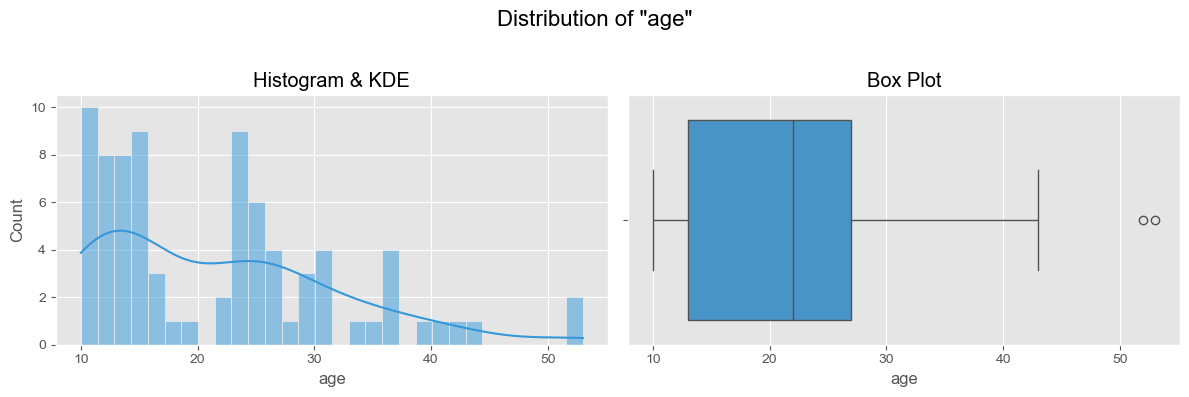

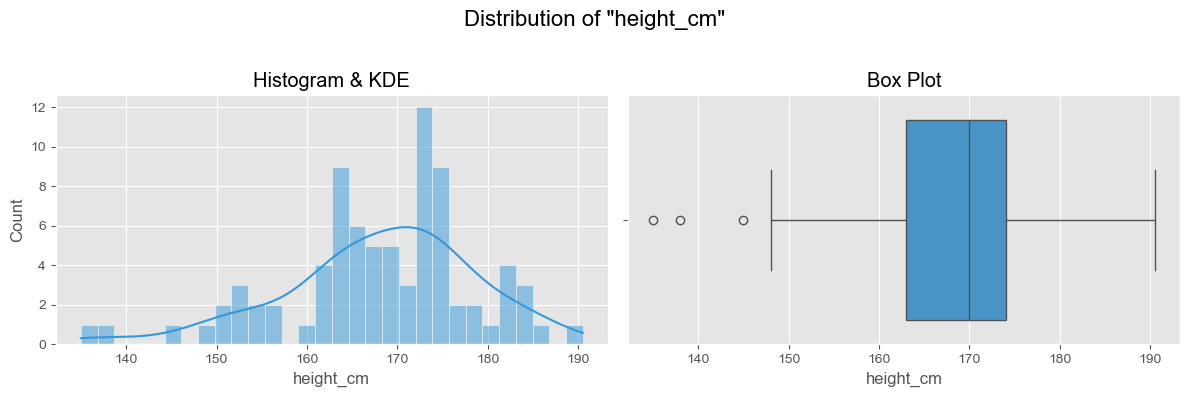

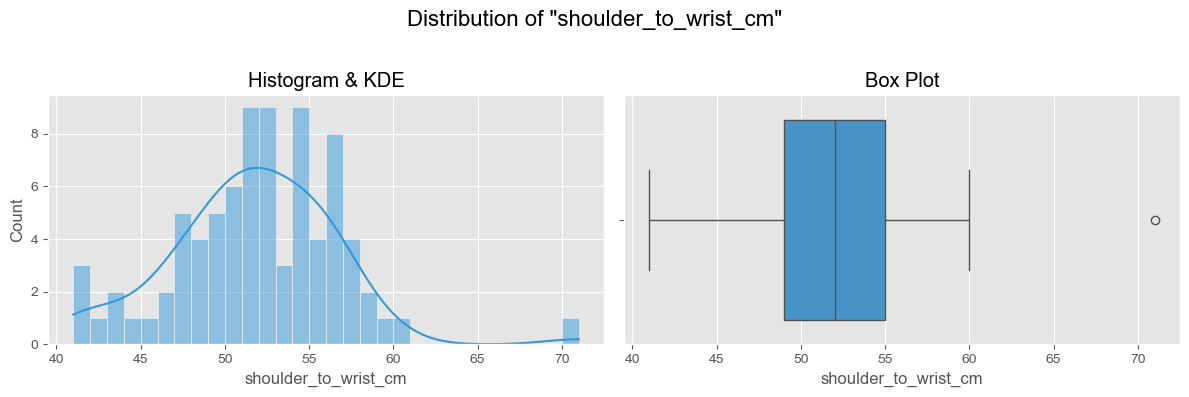

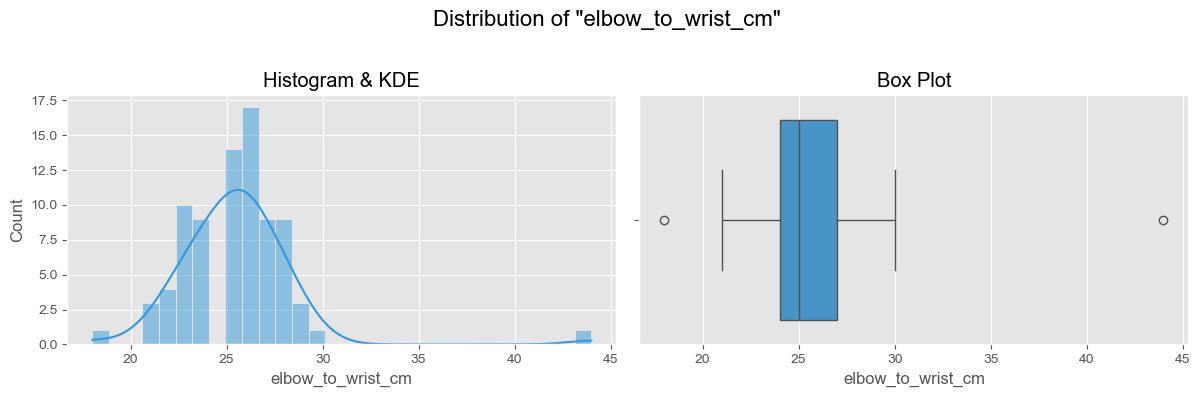

In [22]:
# 分析から除外するセンサーデータの接頭辞
SENSOR_PREFIXES: Tuple[str, ...] = ('acc_', 'rot_', 'thm_', 'tof_')

# 分析から除-外するカテゴリ変数とターゲット変数
EXCLUDED_COLUMNS: List[str] = [
    'phase', 'behavior', 'orientation', 'sequence_type',
    'adult_child', 'sex', 'handedness', 'gesture']

"""データフレームから分析対象の数値列のみを抽出する"""
def get_numerical_columns(
    df: pd.DataFrame,
    excluded_prefixes: Tuple[str, ...],
    excluded_columns: List[str]
) -> List[str]:
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    return [
        col for col in numerical_cols
        if not col.startswith(excluded_prefixes) and col not in excluded_columns
    ]

"""データフレーム内のカテゴリカル変数の分布をプロットする。"""
def plot_categorical_distributions(df: pd.DataFrame, title: str):
    print(f"\n--- {title}: カテゴリカル変数の分布 ---")
    target_cols = get_numerical_columns(df, SENSOR_PREFIXES, EXCLUDED_COLUMNS)
    
    # サブプロットのレイアウトを計算
    n_cols = 3
    n_rows = (len(target_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten() # 常に1次元配列として扱う

    for i, col in enumerate(target_cols):
        sns.histplot(data=df, x=col, ax=axes[i], bins=30) 
        axes[i].set_title(f'Distribution of "{col}"')
        axes[i].tick_params(axis='x', rotation=45) # ラベルが長い場合は回転

    # 不要なサブプロットを非表示にする
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

""" データフレーム内の数値変数の分布をプロットします。"""
def plot_numerical_distributions(df: pd.DataFrame, title: str):
    print(f"\n--- {title}: 数値変数の分布 ---")
    target_cols = get_numerical_columns(df, SENSOR_PREFIXES, EXCLUDED_COLUMNS)
    for col in target_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'Distribution of "{col}"', fontsize=16)

        # ヒストグラムとカーネル密度推定
        sns.histplot(data=df, x=col, kde=True, ax=axes[0], bins=30)
        axes[0].set_title("Histogram & KDE")

        # 箱ひげ図
        sns.boxplot(data=df, x=col, ax=axes[1])
        axes[1].set_title("Box Plot")
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

""" 実行フェーズ """
plot_categorical_distributions(train_df, "train")
plot_numerical_distributions(train_dem_df, "train demographics")



--- train demographics: 数値変数の相関分析 ---


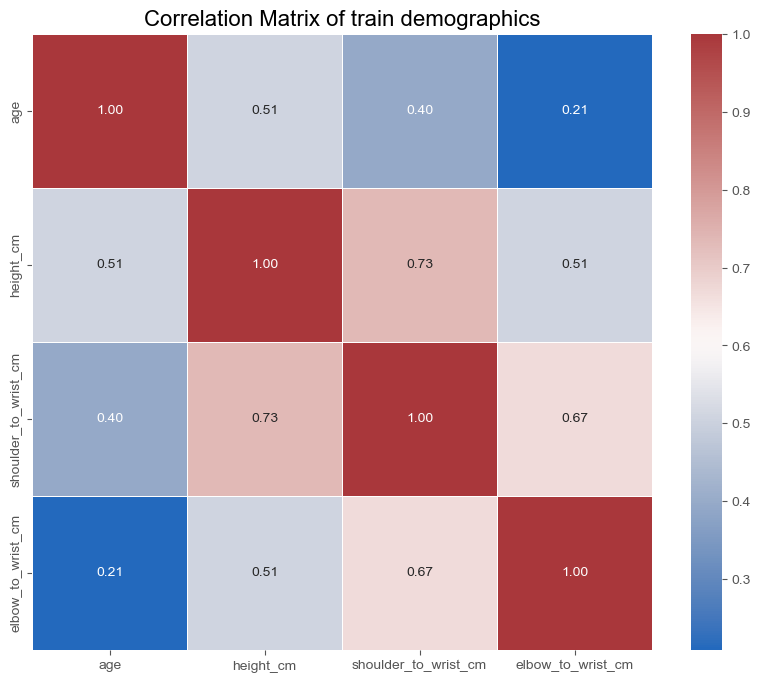

In [ ]:
# 相関関係の分析
""" データフレーム内の数値変数の相関ヒートマップを描画する """
def plot_correlation_heatmap(df: pd.DataFrame, title: str):
    print(f"\n--- {title}: 数値変数の相関分析 ---")
    # numerical_df = df.select_dtypes(include=np.number)
    target_cols = get_numerical_columns(df, SENSOR_PREFIXES, EXCLUDED_COLUMNS)

    # 相関行列を計算
    corr_matrix = df[target_cols].corr()

    # グラフの描画設定
    plt.figure(figsize=(10, 8))
    
    # 特徴量が多い場合は数値を非表示にする
    show_annot = True if len(corr_matrix) <= 15 else False

    # ヒートマップの描画
    sns.heatmap(
        corr_matrix,
        annot=show_annot,  # 条件に応じて数値を表示
        cmap='vlag',       # 発散カラーマップ（青:正, 赤:負）
        fmt='.2f',         # 数値のフォーマット
        linewidths=.5
    )
    plt.title(f'Correlation Matrix of {title}', fontsize=16)
    plt.show()

""" 実行フェーズ """
plot_correlation_heatmap(train_dem_df, "train demographics")

### EDA2 (ミクロ分析)
センサーデータの特性を調べる

## 最後に
ここまで読んでいただきありがとうございました。私はデータ分析の学習のためにkaggleのコンペティションに参加しています。何かアドバイスや疑問点があればお気軽にコメントしてください。日本語でも英語でもどちらでも対応しています。...